# Analisis exploratorio de ventas (puntos 2.a y 2.b)

Este notebook obtiene los datos desde PostgreSQL y calcula media, mediana y moda para las variables cuantitativas. Los resultados de Pandas se contrastan de forma independiente con SQL.

## Criterio de seleccion

Se analizan `edad`, `venta_total`, `n_compras`, `monto_compra` y `tiempo`. Se excluyen identificadores y categorias codificadas (`genero`, `metodo_pago`, `navegador`, `boletin` y `vale`) porque sus promedios no tienen una interpretacion valida.

## Preparacion del entorno

En Google Colab, agregue `DB_HOST`, `DB_PORT`, `DB_NAME`, `DB_USER` y `DB_PASSWORD` en el panel **Secrets** y habilite su acceso. La siguiente celda instala las dependencias, clona el repositorio y crea un archivo `.env` temporal sin mostrar las credenciales. En Jupyter local se utiliza el repositorio y el `.env` existentes.

In [1]:
import os
import subprocess
import sys
from pathlib import Path

EN_COLAB = 'google.colab' in sys.modules
REPOSITORIO = 'https://github.com/AngelMendoz/SOG2-2S26_grupo8.git'

if EN_COLAB:
    subprocess.run(
        [sys.executable, '-m', 'pip', 'install', '-q',
         'numpy>=1.26', 'pandas>=2.2', 'psycopg2-binary>=2.9',
         'python-dotenv>=1.0', 'SQLAlchemy>=2.0'],
        check=True,
    )
    raiz_repositorio = Path('/content/SOG2-2S26_grupo8')
    if not raiz_repositorio.is_dir():
        subprocess.run(['git', 'clone', '--depth', '1', REPOSITORIO, str(raiz_repositorio)], check=True)
    RAIZ_PRACTICA = raiz_repositorio / 'Practica_1'

    from google.colab import userdata

    nombres_secretos = ('DB_HOST', 'DB_PORT', 'DB_NAME', 'DB_USER', 'DB_PASSWORD')
    secretos = {}
    for nombre in nombres_secretos:
        try:
            valor = userdata.get(nombre)
        except Exception as error:
            raise ValueError(f'Falta habilitar el secreto {nombre} en Google Colab.') from error
        if not valor:
            raise ValueError(f'El secreto {nombre} esta vacio en Google Colab.')
        secretos[nombre] = valor
    (RAIZ_PRACTICA / '.env').write_text(
        ''.join(f'{nombre}={valor}\n' for nombre, valor in secretos.items()),
        encoding='utf-8',
    )
else:
    RAIZ_PRACTICA = Path.cwd().resolve()
    if not (RAIZ_PRACTICA / 'app').is_dir():
        RAIZ_PRACTICA = RAIZ_PRACTICA.parent

if not (RAIZ_PRACTICA / 'app').is_dir():
    raise FileNotFoundError('No se encontro la carpeta Practica_1.')

print(f'Entorno listo: {RAIZ_PRACTICA}')

Entorno listo: C:\Users\jmcr3\Desktop\SOG2-2S26_grupo8\Practica_1


In [2]:
from IPython.display import display

if str(RAIZ_PRACTICA) not in sys.path:
    sys.path.insert(0, str(RAIZ_PRACTICA))

from app.analisis.punto_02 import ejecutar_analisis

resultado = ejecutar_analisis(
    directorio_resultados=RAIZ_PRACTICA / '02-Analisis-exploratorio' / 'resultados'
)

## 2.a Obtencion desde la base de datos

La funcion anterior abre una transaccion de solo lectura y consulta `public.clientes` y `public.compras` por separado.

In [3]:
print(f"Clientes obtenidos: {len(resultado['clientes']):,}")
print(f"Compras obtenidas:  {len(resultado['compras']):,}")
print(f"Transaccion de solo lectura: {resultado['control']['solo_lectura']}")
display(resultado['clientes'].head())
display(resultado['compras'].head())

Clientes obtenidos: 6,500
Compras obtenidas:  6,500
Transaccion de solo lectura: on


,id_cliente,edad,genero,venta_total,n_compras
0,504308,18,1,737.4,8
1,504309,46,1,689.2,17
2,504310,38,0,95.6,1
3,504311,44,1,75.7,2
4,504312,41,0,46.0,2


,id_compra,id_cliente,fecha_compra,monto_compra,metodo_pago,tiempo,navegador,boletin,vale
0,1,504308,2021-02-02,109.054,2,1022,0,True,False
1,2,504309,2021-10-10,35.326,1,865,0,False,False
2,3,504310,2021-08-27,89.353,2,900,2,True,True
3,4,504311,2021-06-10,27.220,1,793,0,True,False
4,5,504312,2021-06-08,28.531,0,729,0,False,False


In [4]:
print('Tipos de clientes:')
display(resultado['clientes'].dtypes.rename('tipo').to_frame())
print('Tipos de compras:')
display(resultado['compras'].dtypes.rename('tipo').to_frame())
print('Validaciones de extraccion e integridad:')
display(resultado['validaciones'])

Tipos de clientes:


,tipo
id_cliente,int64
edad,int64
genero,int64
venta_total,float64
n_compras,int64


Tipos de compras:


,tipo
id_compra,int64
id_cliente,int64
fecha_compra,datetime64[s]
monto_compra,float64
metodo_pago,int64
tiempo,int64
navegador,int64
boletin,boolean
vale,boolean


Validaciones de extraccion e integridad:


,validacion,cumple,detalle
0,clientes no vacio,True,6500 filas
1,compras no vacio,True,6500 filas
2,id_cliente unico,True,6500 identificadores unicos
3,id_compra unico,True,6500 identificadores unicos
4,sin nulos en clientes,True,0 valores nulos
5,sin nulos en compras,True,0 valores nulos
6,sin compras huerfanas,True,0 huerfanas
7,dominio de genero,True,"valores: [0, 1]"
8,dominio de metodo_pago,True,"valores: [0, 1, 2]"
9,dominio de navegador,True,"valores: [0, 1, 2, 3, 4]"


## 2.b Estadisticas basicas

No se redondean los datos antes del calculo. La columna `moda` conserva todos los empates y `frecuencia_moda` indica cuantas veces aparece cada valor modal.

In [5]:
columnas = ['tabla', 'variable', 'unidad', 'cantidad', 'nulos', 'media', 'mediana', 'moda', 'frecuencia_moda', 'cantidad_modas']
display(resultado['estadisticas'][columnas].style.format({'media': '{:.4f}', 'mediana': '{:.4f}'}))

,tabla,variable,unidad,cantidad,nulos,media,mediana,moda,frecuencia_moda,cantidad_modas
0,clientes,edad,anios,6500,0,36.3052,36.0000,18,465,1
1,clientes,venta_total,moneda,6500,0,206.2424,137.3500,98,12,1
2,clientes,n_compras,compras,6500,0,5.0900,4.0000,2,1044,1
3,compras,monto_compra,moneda,6500,0,39.7871,35.7640,37.145,5,1
4,compras,tiempo,segundos,6500,0,767.3762,768.0000,852,24,1


## Verificacion independiente con PostgreSQL

PostgreSQL recalcula las medidas con `AVG`, `percentile_cont(0.5)` y frecuencias agrupadas. Todas las columnas `todo_coincide` deben ser verdaderas.

In [6]:
columnas_contraste = ['tabla', 'variable', 'media_coincide', 'mediana_coincide', 'moda_coincide', 'frecuencia_moda_coincide', 'todo_coincide']
display(resultado['contraste'][columnas_contraste])
assert resultado['validaciones']['cumple'].all()
assert resultado['contraste']['todo_coincide'].all()
print('Analisis verificado: la extraccion es integra y Pandas coincide con PostgreSQL.')

,tabla,variable,media_coincide,mediana_coincide,moda_coincide,frecuencia_moda_coincide,todo_coincide
0,clientes,edad,True,True,True,True,True
1,clientes,venta_total,True,True,True,True,True
2,clientes,n_compras,True,True,True,True,True
3,compras,monto_compra,True,True,True,True,True
4,compras,tiempo,True,True,True,True,True


Analisis verificado: la extraccion es integra y Pandas coincide con PostgreSQL.


## Nota de interpretacion

`venta_total` y `n_compras` son acumulados anuales del cliente. `monto_compra` y `fecha_compra` describen la fila registrada en `compras`. Las tablas se mantienen separadas para no duplicar los acumulados de cliente si se agregan mas compras en el futuro.

## 2.c Distribucion de ventas

Se analiza como se distribuyen las compras y los montos de `compras` segun mes, metodo de pago, navegador, boletin y vale. Se reutiliza `resultado['compras']`, obtenido en la extraccion de 2.a, sin volver a consultar la base de datos.

In [7]:
from app.analisis.punto_02 import (
    distribucion_ventas_por_mes,
    distribucion_ventas_por_metodo_pago,
    distribucion_ventas_por_navegador,
    distribucion_ventas_por_boletin,
    distribucion_ventas_por_vale,
)

directorio_resultados_distribucion = RAIZ_PRACTICA / '02-Analisis-exploratorio' / 'resultados'

### Distribucion por mes

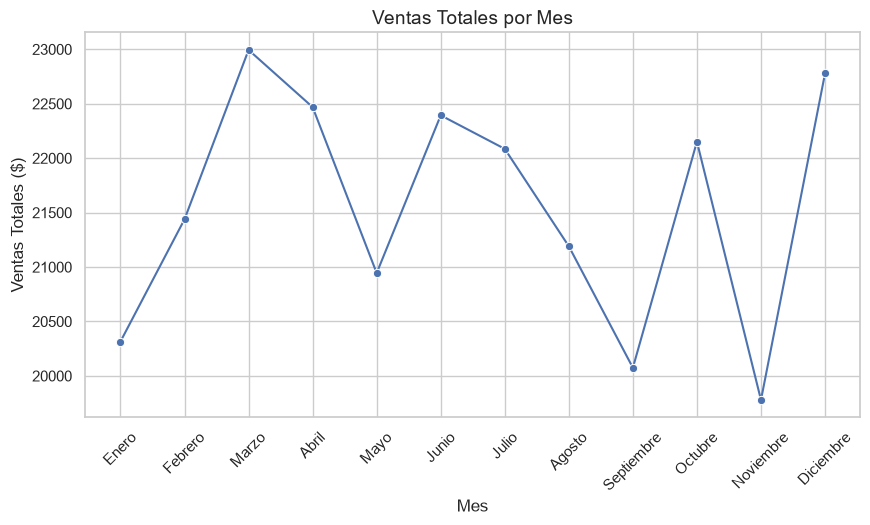

,mes,mes_nombre,cantidad_compras,monto_total,monto_promedio
0,1,Enero,520,20315.897,39.069033
1,2,Febrero,545,21438.811,39.337268
2,3,Marzo,569,22994.336,40.411838
3,4,Abril,557,22468.965,40.339255
4,5,Mayo,530,20944.681,39.518266
5,6,Junio,543,22393.603,41.240521
6,7,Julio,565,22085.577,39.089517
7,8,Agosto,530,21190.510,39.982094
8,9,Septiembre,508,20074.825,39.517372
9,10,Octubre,563,22151.327,39.345163


In [8]:
distribucion_mes = distribucion_ventas_por_mes(
    resultado['compras'], directorio_resultados=directorio_resultados_distribucion
)
display(distribucion_mes)

### Distribucion por metodo de pago

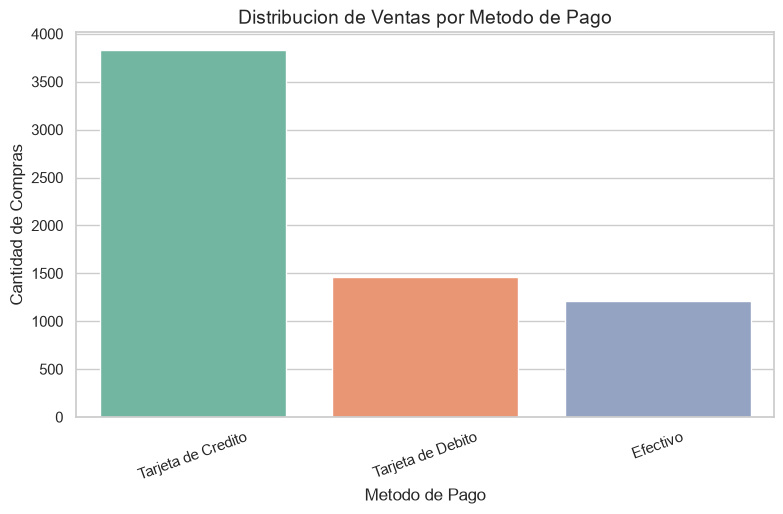

,metodo_pago_desc,cantidad_compras,monto_total,monto_promedio
0,Tarjeta de Credito,3827,152601.474,39.874961
1,Tarjeta de Debito,1466,58548.743,39.937751
2,Efectivo,1207,47465.644,39.325306


In [9]:
distribucion_metodo_pago = distribucion_ventas_por_metodo_pago(
    resultado['compras'], directorio_resultados=directorio_resultados_distribucion
)
display(distribucion_metodo_pago)

### Distribucion por navegador

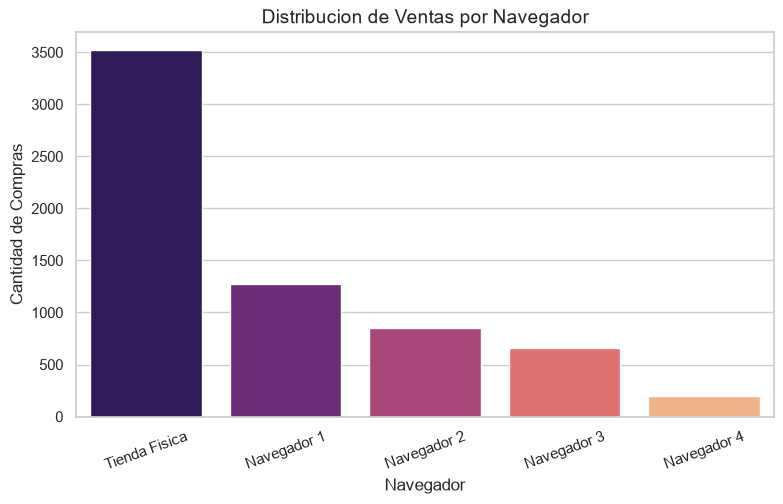

,navegador_desc,cantidad_compras,monto_total,monto_promedio
0,Tienda Fisica,3523,140332.264,39.833172
1,Navegador 1,1273,51323.342,40.316844
2,Navegador 2,847,33405.457,39.439737
3,Navegador 3,660,25412.699,38.504089
4,Navegador 4,197,8142.099,41.330452


In [10]:
distribucion_navegador = distribucion_ventas_por_navegador(
    resultado['compras'], directorio_resultados=directorio_resultados_distribucion
)
display(distribucion_navegador)

### Distribucion por boletin

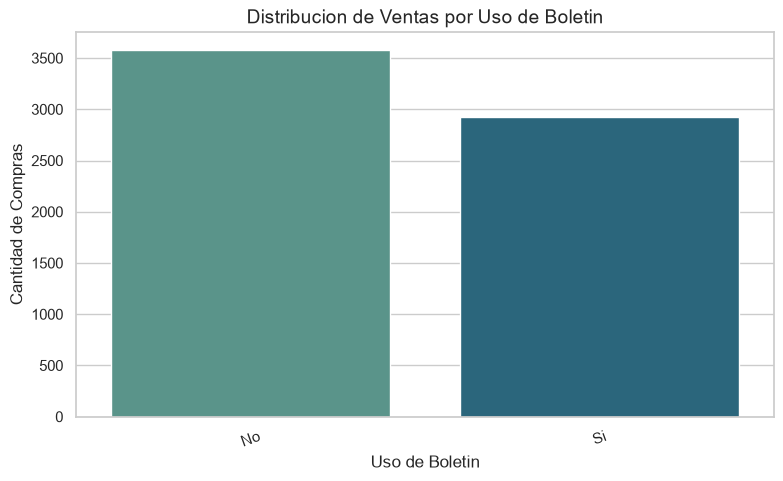

,boletin_desc,cantidad_compras,monto_total,monto_promedio
0,No,3579,139321.974,38.927626
1,Si,2921,119293.887,40.840085


In [11]:
distribucion_boletin = distribucion_ventas_por_boletin(
    resultado['compras'], directorio_resultados=directorio_resultados_distribucion
)
display(distribucion_boletin)

### Distribucion por vale

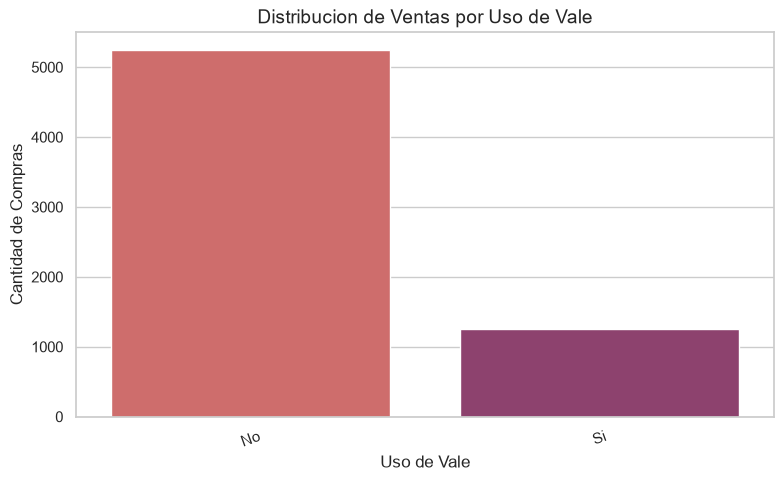

,vale_desc,cantidad_compras,monto_total,monto_promedio
0,No,5246,202245.049,38.552240
1,Si,1254,56370.812,44.952801


In [12]:
distribucion_vale = distribucion_ventas_por_vale(
    resultado['compras'], directorio_resultados=directorio_resultados_distribucion
)
display(distribucion_vale)